<a href="https://colab.research.google.com/github/ntlcs/fiap-pos-ia-tech-challenge-fase-1/blob/main/01_Desafio_FIAP_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Estrutura do notebook

Este notebook foi organizado seguindo as principais etapas de um projeto de Ciência de Dados baseado na metodologia CRISP-DM:

1. Compreensão do problema
2. Entendimento dos dados
3. Análise exploratória (EDA)
4. Pré-processamento
5. Modelagem
6. Avaliação
7. Discussão crítica
8. Conclusão

# Tech Challenge - Fase 1 FIAP

## Sistema Inteligente de Apoio ao Diagnóstico de Diabetes com Machine Learning

Este notebook tem como objetivo desenvolver uma solução de Machine Learning para apoio à triagem inicial de pacientes com possível diagnóstico de diabetes.

O projeto contempla:

- entendimento do problema;
- análise exploratória dos dados;
- avaliação da qualidade dos dados;
- pré-processamento;
- treinamento de modelos;
- avaliação com métricas adequadas ao contexto médico;
- interpretação dos resultados;
- discussão crítica sobre limitações e uso em produção.

# 1. Entendimento do problema

O desafio proposto pela FIAP apresenta o contexto de um hospital universitário que busca utilizar Inteligência Artificial para apoiar profissionais de saúde na análise inicial de exames e dados clínicos.

Neste projeto, o problema foi tratado como uma tarefa de classificação supervisionada, cujo objetivo é prever se uma paciente apresenta ou não indicativo de diabetes a partir de variáveis clínicas.

A variável alvo é `Outcome`, em que:

- `0`: paciente sem indicativo de diabetes;
- `1`: paciente com indicativo de diabetes.

Por se tratar de um problema relacionado à saúde, a avaliação do modelo não deve se limitar à acurácia. Métricas como Recall, Precision, F1-score e ROC-AUC são essenciais, especialmente porque falsos negativos podem representar pacientes doentes classificados incorretamente como saudáveis.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

# 2. Carregamento dos dados

O dataset utilizado contém informações clínicas de pacientes e será utilizado para prever a presença ou ausência de diabetes.

A leitura dos dados deve ser reprodutível, garantindo que qualquer avaliador consiga executar o notebook do início ao fim.

In [6]:
try:
    import kagglehub

    path = kagglehub.dataset_download("mathchi/diabetes-data-set")
    csv_path = os.path.join(path, "diabetes.csv")
    df = pd.read_csv(csv_path)

except Exception:
    df = pd.read_csv("diabetes.csv")

df.head()

100%|██████████| 8.91k/8.91k [00:00<00:00, 9.65MB/s]

Extracting files...


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 3. Inspeção inicial dos dados

Nesta etapa, avaliamos a estrutura básica do dataset: quantidade de linhas, colunas, tipos de dados e primeiras observações.

Essa verificação inicial é importante para confirmar se os dados foram carregados corretamente e se a estrutura está compatível com o problema de classificação.

In [7]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

display(df.head())
display(df.tail())
display(df.info())

Linhas: 768
Colunas: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

# 4. Dicionário dos dados

| Variável | Descrição |
|---|---|
| Pregnancies | Número de gestações |
| Glucose | Concentração de glicose |
| BloodPressure | Pressão arterial |
| SkinThickness | Espessura da dobra cutânea |
| Insulin | Nível de insulina |
| BMI | Índice de massa corporal |
| DiabetesPedigreeFunction | Função de histórico familiar de diabetes |
| Age | Idade |
| Outcome | Variável alvo: 0 = não diabético, 1 = diabético |

# 5. Estatísticas descritivas

A análise estatística inicial permite observar tendência central, dispersão, amplitude e possíveis inconsistências nos dados.

Nesta etapa, valores mínimos iguais a zero em variáveis clínicas merecem atenção, pois podem representar ausência de informação codificada como zero.

In [8]:
estatisticas = df.describe().T
estatisticas["mediana"] = df.median(numeric_only=True)
estatisticas["assimetria"] = df.skew(numeric_only=True)
estatisticas["curtose"] = df.kurt(numeric_only=True)

display(estatisticas.round(2))

,count,mean,std,min,25%,50%,75%,max,mediana,assimetria,curtose
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00,3.00,0.90,0.16
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00,117.00,0.17,0.64
BloodPressure,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00,72.00,-1.84,5.18
SkinThickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00,23.00,0.11,-0.52
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00,30.50,2.27,7.21
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10,32.00,-0.43,3.29
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42,0.37,1.92,5.59
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00,29.00,1.13,0.64
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00,0.00,0.64,-1.60


# 6. Qualidade dos dados

Nesta etapa são avaliados:

- valores nulos explícitos;
- registros duplicados;
- valores únicos;
- possíveis inconsistências clínicas.

Mesmo quando não existem valores nulos explícitos, variáveis clínicas com valor zero podem indicar ausência de informação.

In [9]:
qualidade = pd.DataFrame({
    "tipo": df.dtypes,
    "nulos": df.isna().sum(),
    "nulos_percentual": df.isna().mean().mul(100).round(2),
    "valores_unicos": df.nunique()
})

display(qualidade)

duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

,tipo,nulos,nulos_percentual,valores_unicos
Pregnancies,int64,0,0.0,17
Glucose,int64,0,0.0,136
BloodPressure,int64,0,0.0,47
SkinThickness,int64,0,0.0,51
Insulin,int64,0,0.0,186
BMI,float64,0,0.0,248
DiabetesPedigreeFunction,float64,0,0.0,517
Age,int64,0,0.0,52
Outcome,int64,0,0.0,2


Registros duplicados: 0


# 7. Investigação de valores iguais a zero

Algumas variáveis clínicas não deveriam apresentar valor zero em condições reais, como glicose, pressão arterial, insulina, IMC e espessura da pele.

Esses valores provavelmente representam dados ausentes codificados como zero. Mantê-los sem tratamento pode distorcer médias, correlações, gráficos e modelos de Machine Learning.

In [10]:
colunas_zero_invalidas = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zeros = pd.DataFrame({
    "qtd_zeros": (df[colunas_zero_invalidas] == 0).sum(),
    "percentual_zeros": (df[colunas_zero_invalidas] == 0).mean().mul(100).round(2)
})

display(zeros)

,qtd_zeros,percentual_zeros
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


# 8. Distribuição da variável alvo

Antes da modelagem, é necessário verificar se existe desbalanceamento entre as classes.

Em problemas médicos, o desbalanceamento pode prejudicar a capacidade do modelo de identificar corretamente a classe de maior interesse clínico.

,quantidade,percentual
Outcome,,
0,500,65.1
1,268,34.9


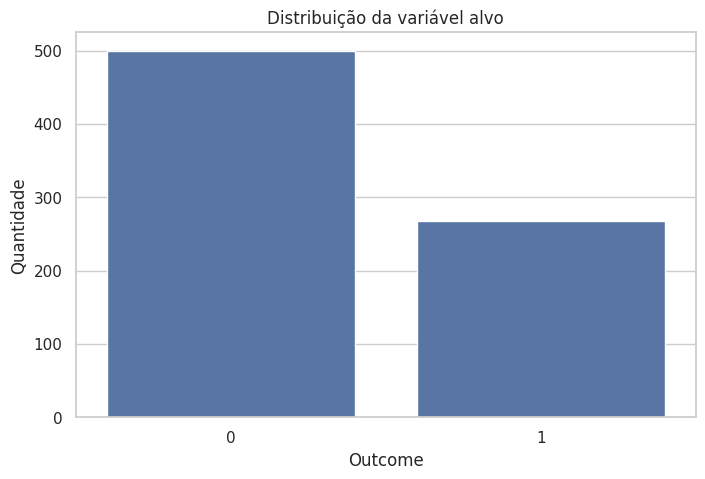

In [11]:
target_count = df["Outcome"].value_counts().sort_index()
target_percent = df["Outcome"].value_counts(normalize=True).sort_index().mul(100).round(2)

display(pd.DataFrame({
    "quantidade": target_count,
    "percentual": target_percent
}))

ax = sns.countplot(data=df, x="Outcome")
ax.set_title("Distribuição da variável alvo")
ax.set_xlabel("Outcome")
ax.set_ylabel("Quantidade")
plt.show()

### Interpretação

A variável alvo apresenta predominância da classe `0`, correspondente às pacientes sem indicativo de diabetes. A classe `1`, embora menor, possui quantidade suficiente para treinamento inicial de modelos supervisionados.

Esse desbalanceamento não é extremo, mas exige cuidado na avaliação. Em contexto médico, um modelo pode apresentar boa acurácia apenas por prever melhor a classe majoritária. Por isso, métricas como Recall, F1-score e ROC-AUC são mais relevantes do que Accuracy isoladamente.


Esse resultado também justifica o uso de divisão estratificada entre treino e teste (`stratify=y`), garantindo que ambas as classes permaneçam representadas em proporções semelhantes durante a modelagem.

# 9. Distribuição das variáveis numéricas

Os histogramas mostram que algumas variáveis apresentam distribuição aproximadamente simétrica, enquanto outras possuem forte assimetria positiva. Essa característica influencia diretamente a escolha das técnicas de imputação, escalonamento e dos modelos de Machine Learning mais adequados.

Além disso, a presença de valores iguais a zero em variáveis fisiológicas sugere inconsistências que deverão ser tratadas antes da modelagem para evitar aprendizado baseado em informações incorretas.

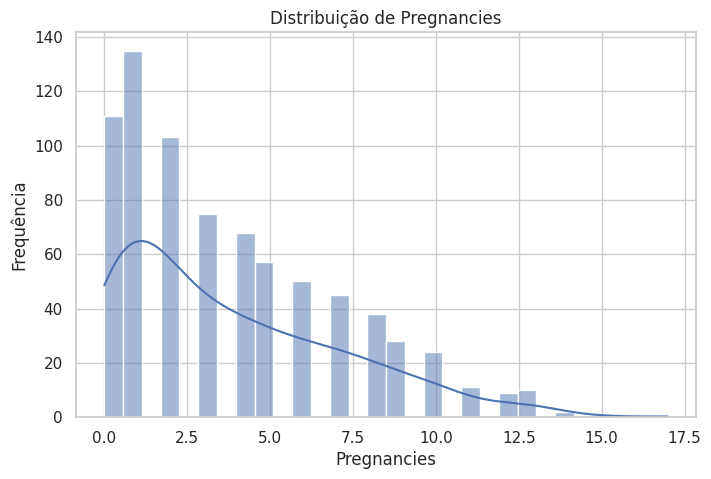

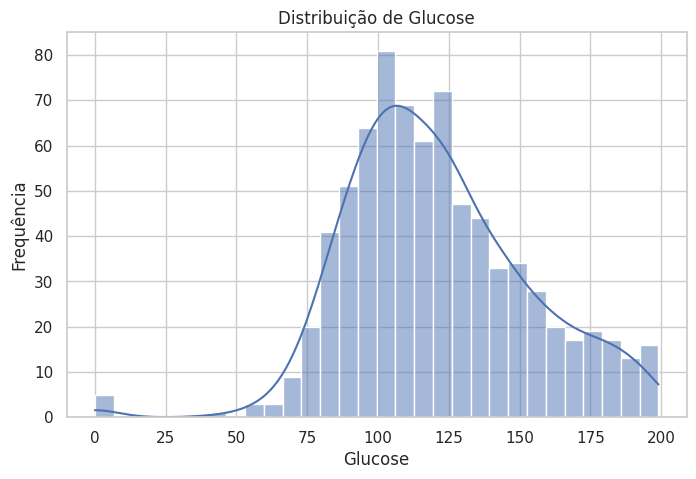

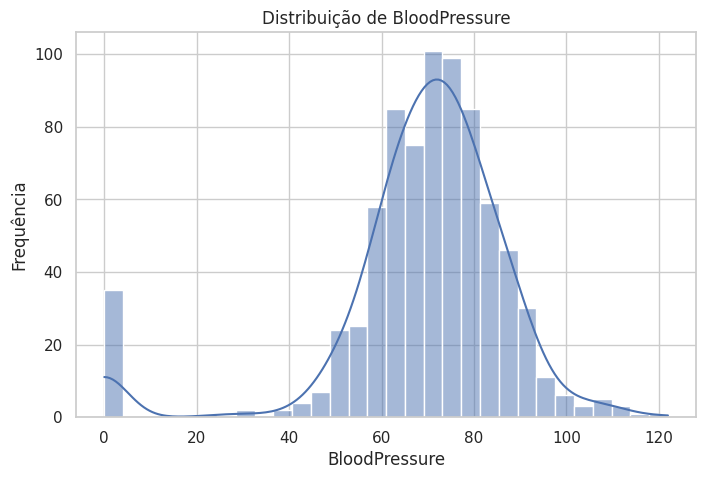

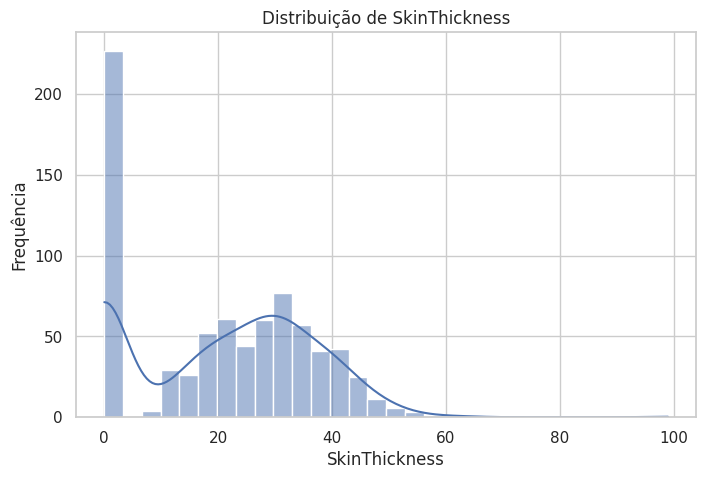

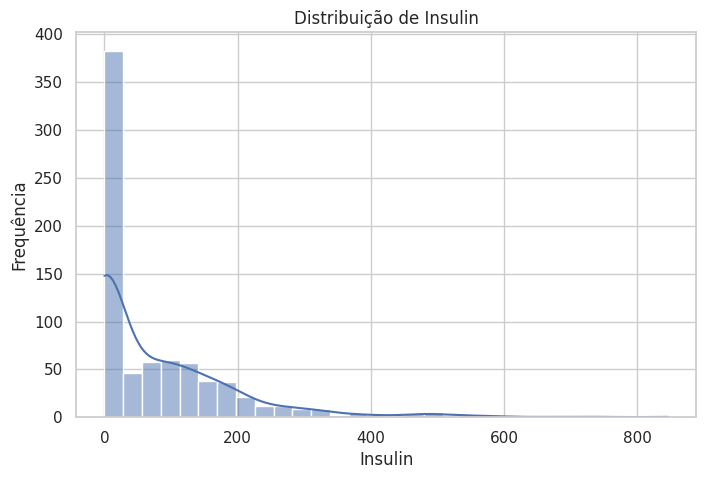

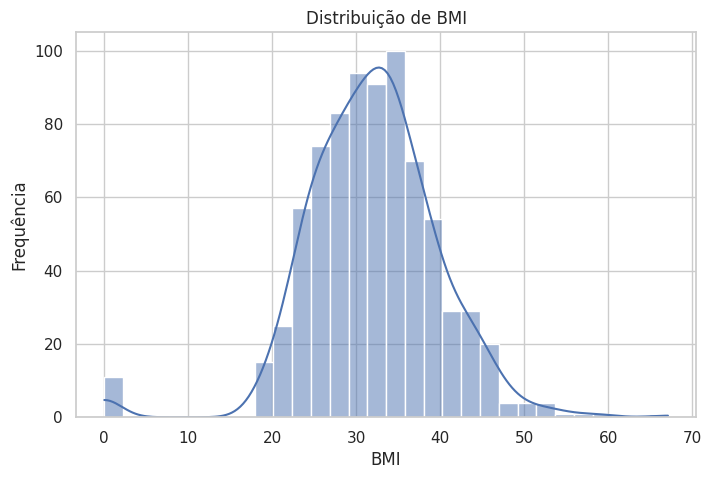

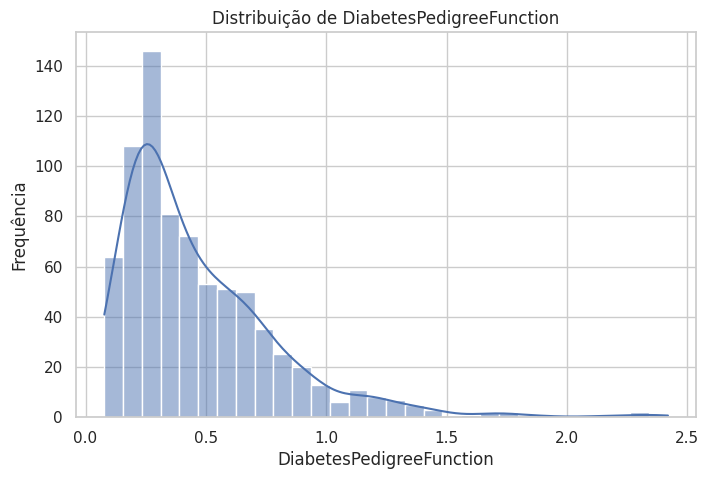

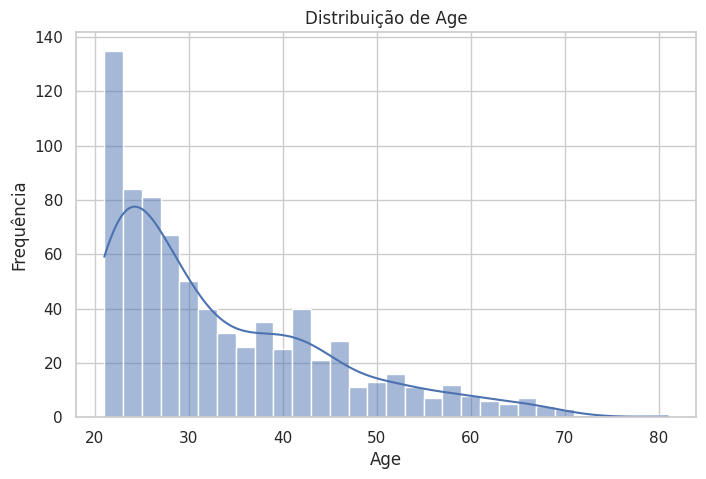

In [12]:
colunas_numericas = df.select_dtypes(include="number").columns.drop("Outcome")

for coluna in colunas_numericas:
    sns.histplot(data=df, x=coluna, kde=True, bins=30)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.show()

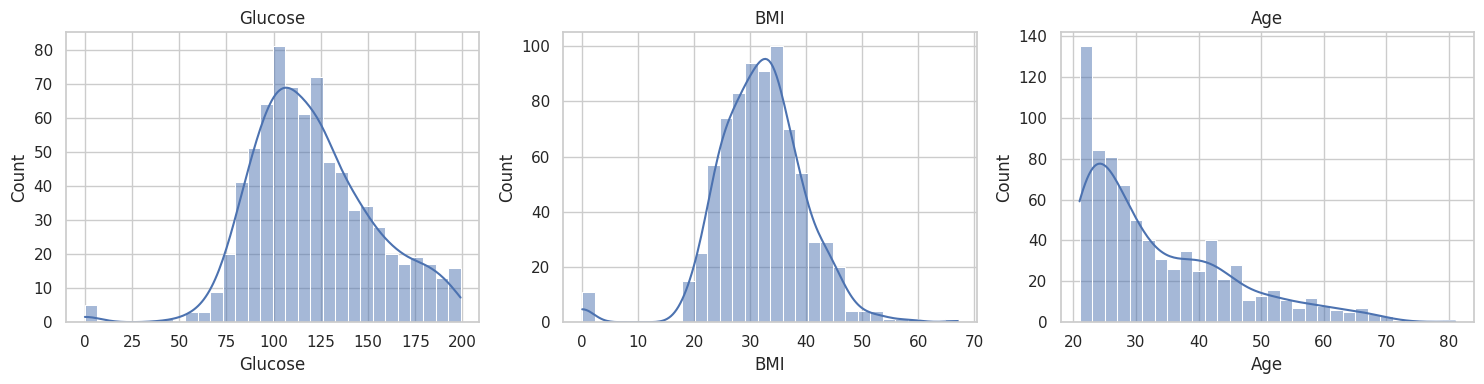

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["Glucose"], kde=True, bins=30, ax=axes[0])
axes[0].set_title("Glucose")

sns.histplot(df["BMI"], kde=True, bins=30, ax=axes[1])
axes[1].set_title("BMI")

sns.histplot(df["Age"], kde=True, bins=30, ax=axes[2])
axes[2].set_title("Age")

plt.tight_layout()
plt.show()

### Interpretação

As distribuições das variáveis numéricas mostram comportamentos diferentes entre os atributos clínicos. Algumas variáveis apresentam assimetria à direita, como `Insulin`, `DiabetesPedigreeFunction` e `Age`, indicando concentração de pacientes em valores menores e presença de poucos registros com valores muito altos.

Também são observados valores iguais a zero em variáveis como `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` e `BMI`. Do ponto de vista clínico, esses zeros não são plausíveis e provavelmente representam dados ausentes codificados incorretamente.

Para Machine Learning, isso é relevante porque modelos podem interpretar esses zeros como valores reais, distorcendo padrões, médias, correlações e decisões de classificação.

# 10. Análise de outliers

Os boxplots ajudam a identificar valores extremos. Em dados médicos, outliers nem sempre são erros: podem representar pacientes com condições clínicas específicas.

Por isso, a decisão de remover outliers deve ser cautelosa e tecnicamente justificada.

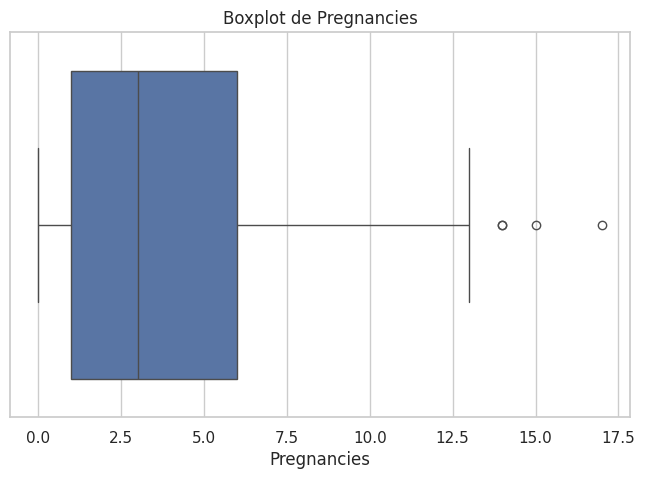

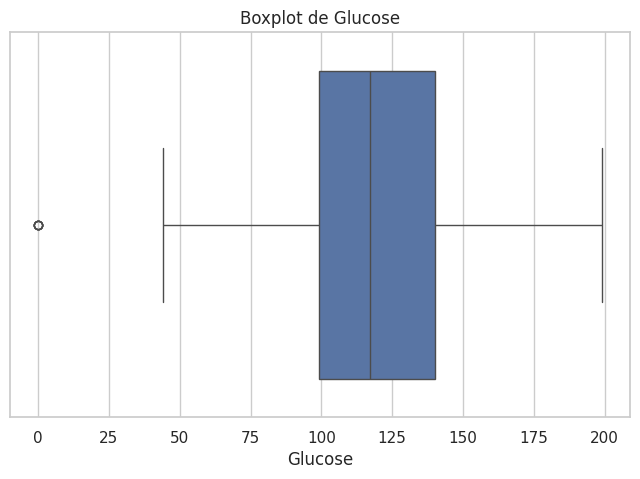

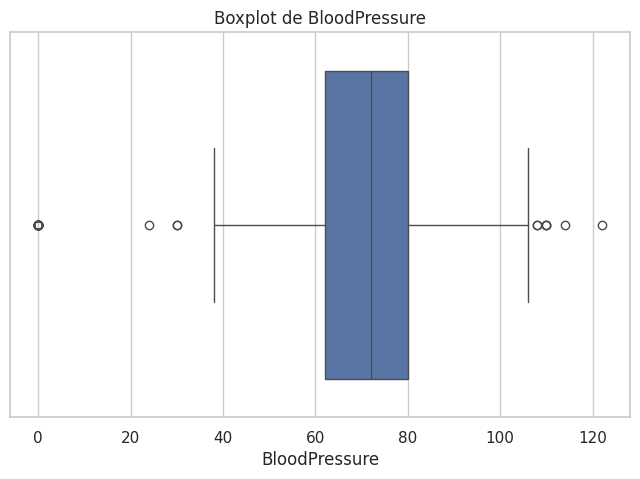

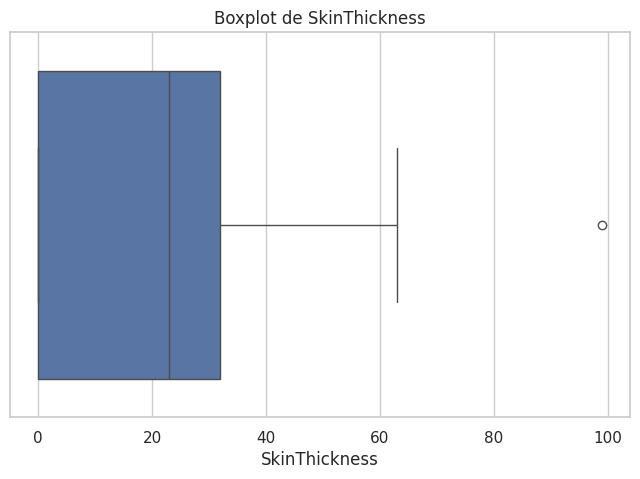

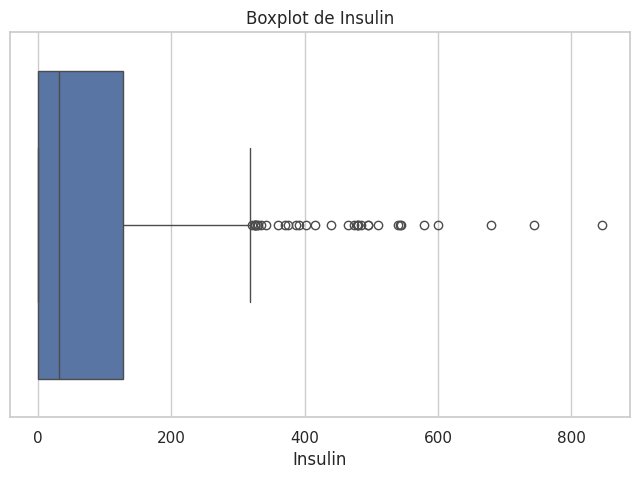

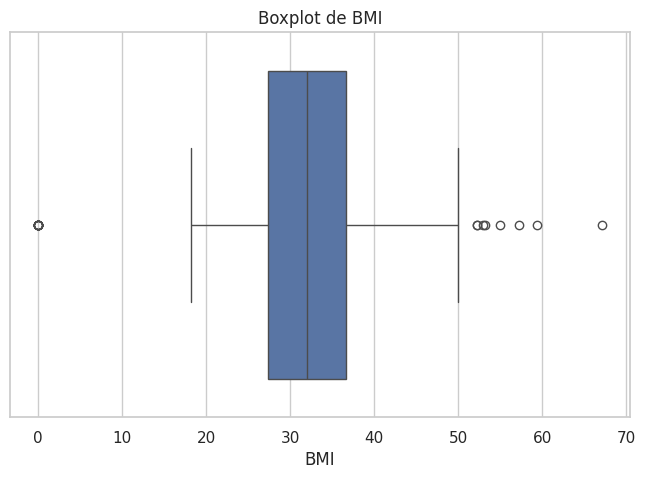

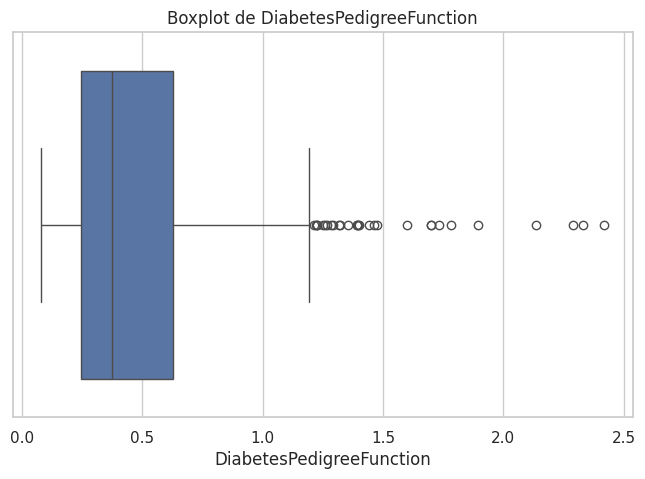

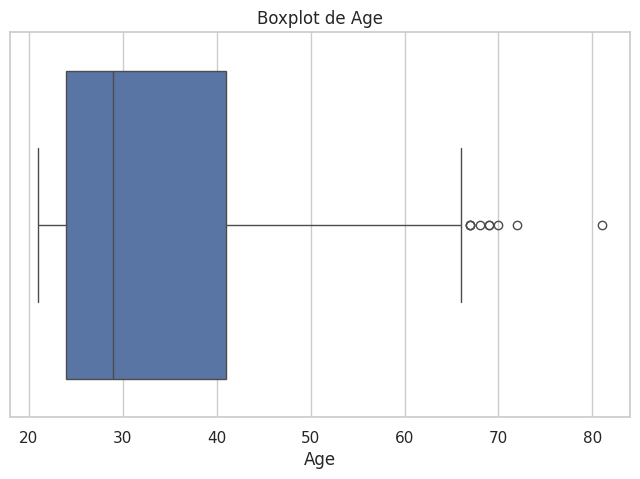

In [14]:
for coluna in colunas_numericas:
    sns.boxplot(x=df[coluna])
    plt.title(f"Boxplot de {coluna}")
    plt.xlabel(coluna)
    plt.show()

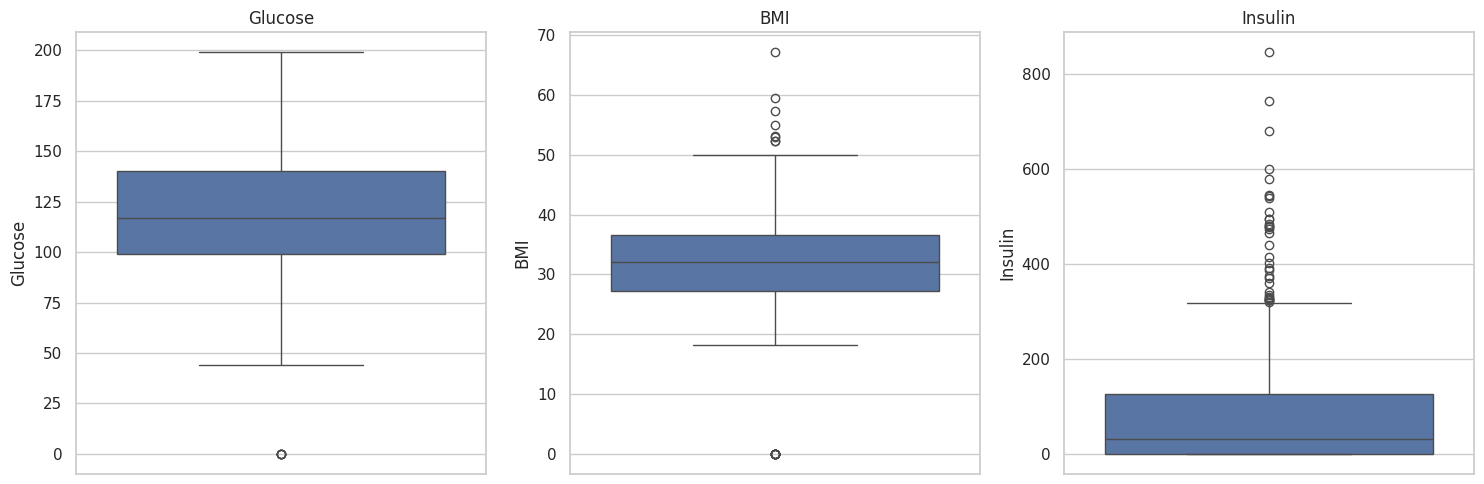

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.boxplot(y=df["Glucose"], ax=axes[0])
axes[0].set_title("Glucose")

sns.boxplot(y=df["BMI"], ax=axes[1])
axes[1].set_title("BMI")

sns.boxplot(y=df["Insulin"], ax=axes[2])
axes[2].set_title("Insulin")

plt.tight_layout()
plt.show()

### Interpretação

Os boxplots indicam presença de outliers em várias variáveis, principalmente em `Insulin`, `DiabetesPedigreeFunction`, `SkinThickness` e `Pregnancies`.

Em dados médicos, outliers não devem ser removidos automaticamente, pois podem representar casos clínicos reais e relevantes. A remoção sem justificativa poderia eliminar justamente pacientes com maior risco ou perfis menos comuns.

A melhor abordagem neste projeto é manter os outliers inicialmente e utilizar modelos mais robustos, além de aplicar imputação adequada para os valores clinicamente inválidos.

In [ ]:
resultado_outliers = []

for coluna in colunas_numericas:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    qtd_outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ].shape[0]

    resultado_outliers.append({
        "variavel": coluna,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "qtd_outliers": qtd_outliers,
        "percentual_outliers": round(qtd_outliers / len(df) * 100, 2)
    })

display(pd.DataFrame(resultado_outliers))

,variavel,limite_inferior,limite_superior,qtd_outliers,percentual_outliers
0,Pregnancies,-6.500,13.500,4,0.52
1,Glucose,37.125,202.125,5,0.65
2,BloodPressure,35.000,107.000,45,5.86
3,SkinThickness,-48.000,80.000,1,0.13
4,Insulin,-190.875,318.125,34,4.43
5,BMI,13.350,50.550,19,2.47
6,DiabetesPedigreeFunction,-0.330,1.200,29,3.78
7,Age,-1.500,66.500,9,1.17


### Interpretação

A análise pelo método IQR confirma a existência de valores extremos em algumas variáveis. Entretanto, o IQR é uma regra estatística genérica e não considera o contexto clínico.

Por isso, os outliers serão tratados com cautela. Neste projeto, eles não serão removidos automaticamente, pois podem conter informação preditiva importante para identificação de pacientes com risco de diabetes.

Embora o método IQR identifique diversos valores extremos, não há evidências suficientes para classificá-los como erros de medição. Em bases clínicas, pacientes com características muito diferentes da média podem representar justamente os casos de maior interesse diagnóstico.

# 11. Correlação entre variáveis

A matriz de correlação permite observar relações lineares entre os atributos.

Correlação não implica causalidade, mas ajuda a identificar variáveis potencialmente relevantes para o modelo.

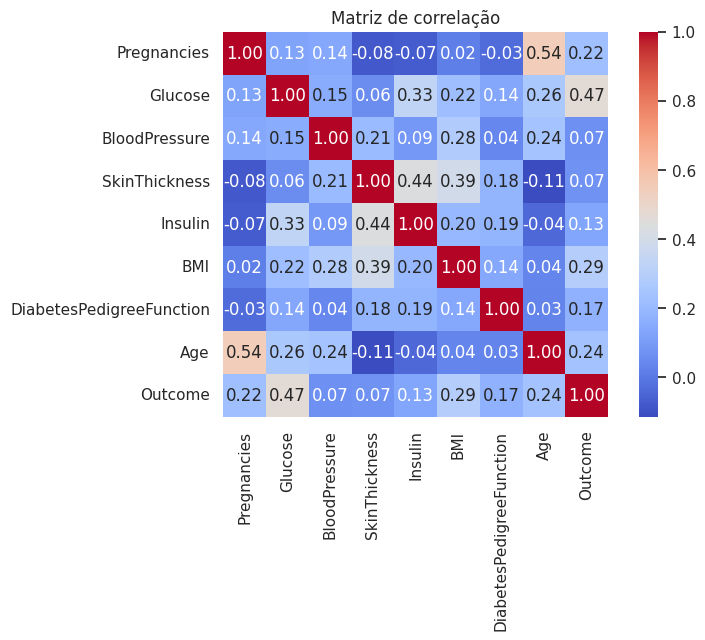

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Matriz de correlação")
plt.show()

### Interpretação

A análise de correlação indica que `Glucose` possui a associação linear positiva mais elevada com a variável alvo dentre os atributos disponíveis nesta base.

Como a correlação de Pearson mede apenas relações lineares, variáveis com baixa correlação ainda podem contribuir significativamente para modelos capazes de capturar relações não lineares, como Random Forest.

Variáveis como `BMI`, `Age` e `Pregnancies` também apresentam associação positiva com a variável alvo, embora mais moderada.

Não há sinais fortes de multicolinearidade extrema entre as variáveis preditoras. Isso é positivo, especialmente para modelos lineares como Regressão Logística.

Ainda assim, correlação não implica causalidade. A análise indica associação estatística, não prova relação causal direta.

,correlacao_com_outcome
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


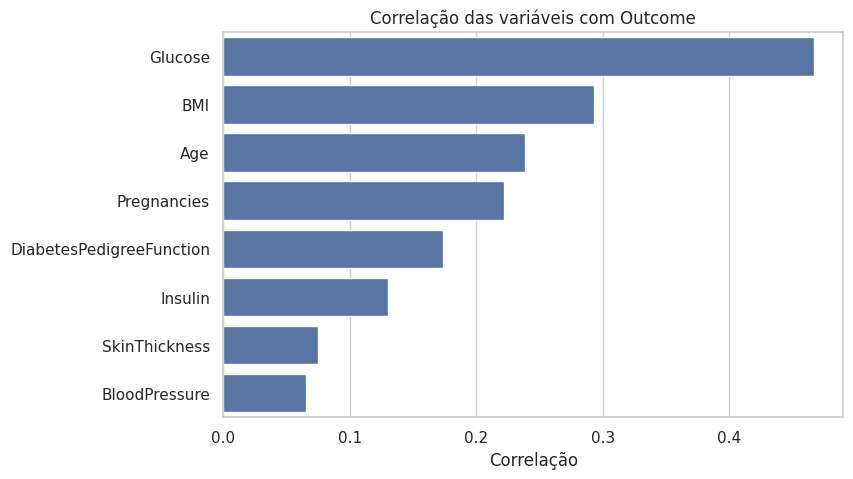

In [ ]:
corr_outcome = (
    df.corr(numeric_only=True)["Outcome"]
    .drop("Outcome")
    .sort_values(ascending=False)
    .to_frame("correlacao_com_outcome")
)

display(corr_outcome)

sns.barplot(
    data=corr_outcome.reset_index(),
    x="correlacao_com_outcome",
    y="index"
)

plt.title("Correlação das variáveis com Outcome")
plt.xlabel("Correlação")
plt.ylabel("")
plt.show()

### Interpretação

A variável `Glucose` se destaca como o principal atributo associado ao diagnóstico positivo. Isso sugere que pacientes com maiores níveis de glicose tendem a apresentar maior probabilidade de diabetes.

`BMI`, `Age` e `Pregnancies` também aparecem como variáveis relevantes, indicando possível relação entre diabetes, idade, composição corporal e histórico gestacional.

Variáveis com correlação mais baixa não devem ser descartadas automaticamente, pois modelos não lineares podem capturar interações que a correlação linear não evidencia.

# 12. Comparação das variáveis por classe

Nesta etapa, comparamos as distribuições das variáveis entre pacientes com e sem indicativo de diabetes.

Essa análise ajuda a identificar quais atributos apresentam diferenças relevantes entre as classes.

In [ ]:
comparacao_classes = df.groupby("Outcome")[colunas_numericas].agg(["mean", "median", "std"]).T

display(comparacao_classes.round(2))

Outcome                               0       1
Pregnancies              mean      3.30    4.87
                         median    2.00    4.00
                         std       3.02    3.74
Glucose                  mean    109.98  141.26
                         median  107.00  140.00
                         std      26.14   31.94
BloodPressure            mean     68.18   70.82
                         median   70.00   74.00
                         std      18.06   21.49
SkinThickness            mean     19.66   22.16
                         median   21.00   27.00
                         std      14.89   17.68
Insulin                  mean     68.79  100.34
                         median   39.00    0.00
                         std      98.87  138.69
BMI                      mean     30.30   35.14
                         median   30.05   34.25
                         std       7.69    7.26
DiabetesPedigreeFunction mean      0.43    0.55
                         median    0.34    0.45
                         std       0.30    0.37
Age                      mean     31.19   37.07
                         median   27.00   36.00
                         std      11.67   10.97

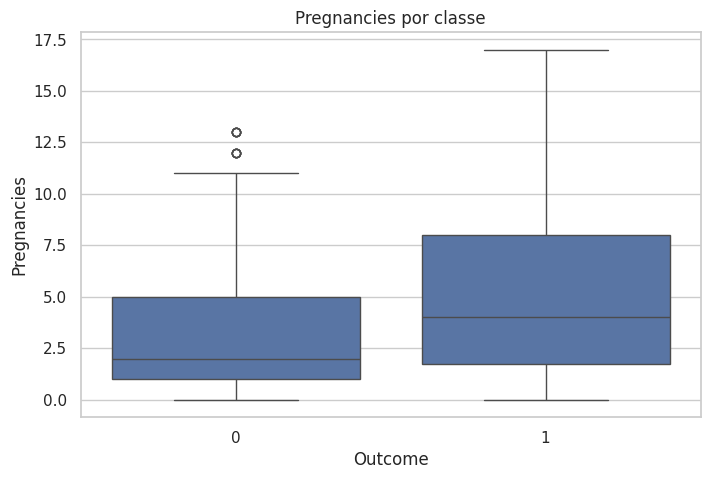

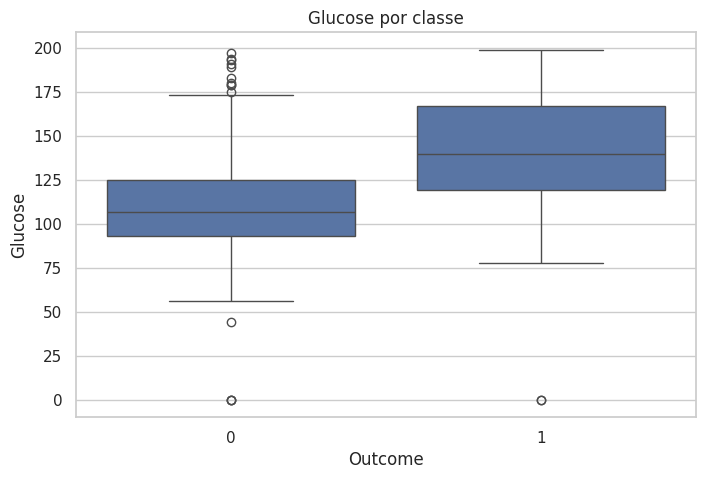

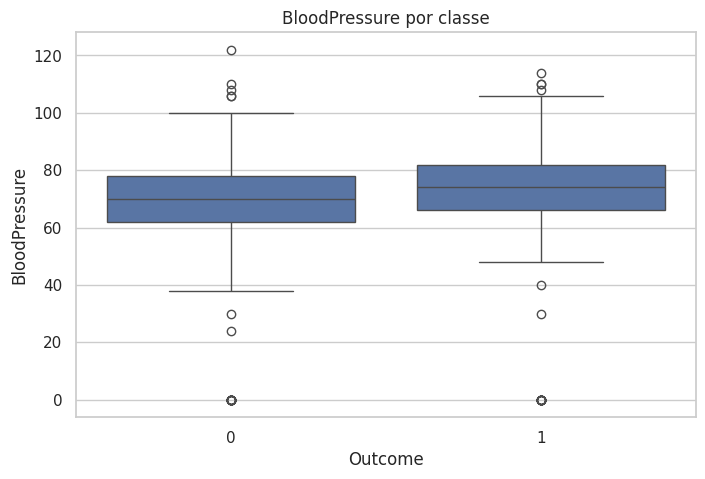

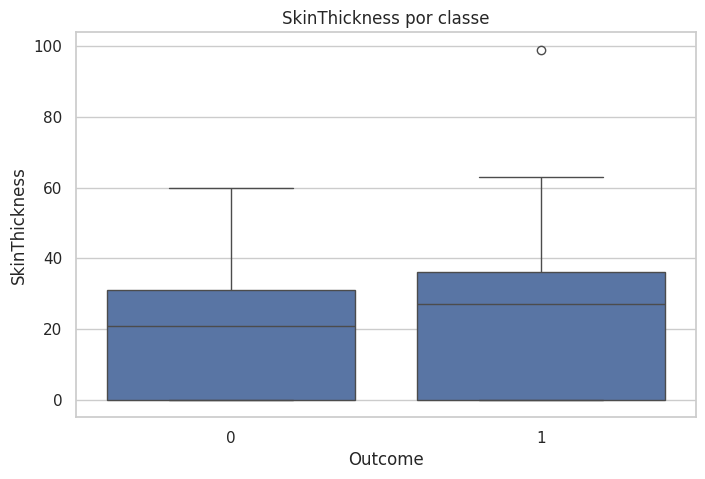

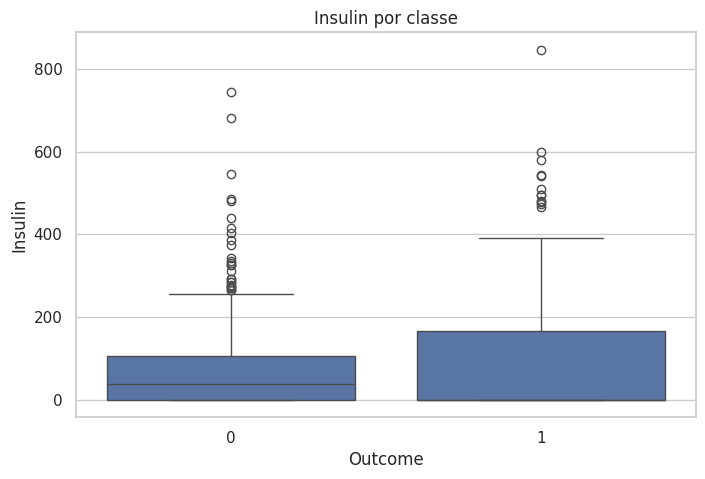

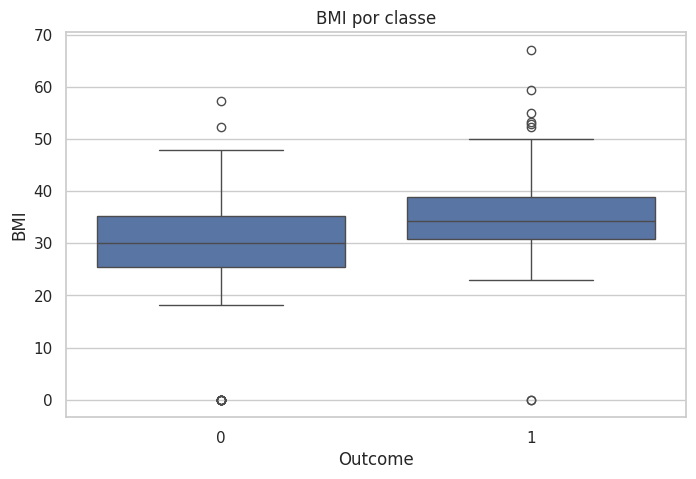

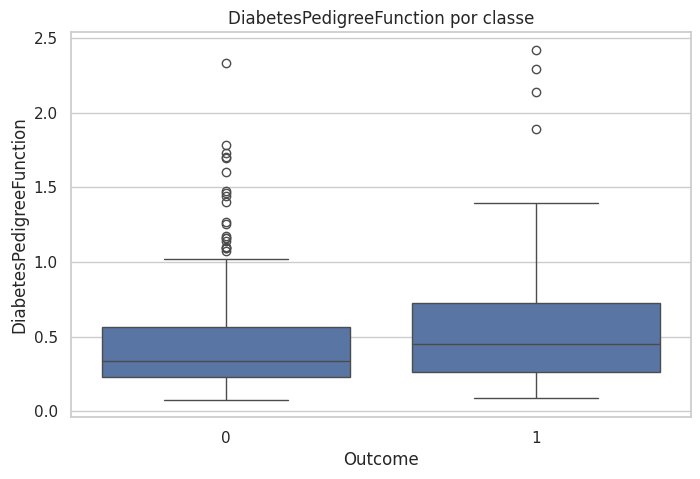

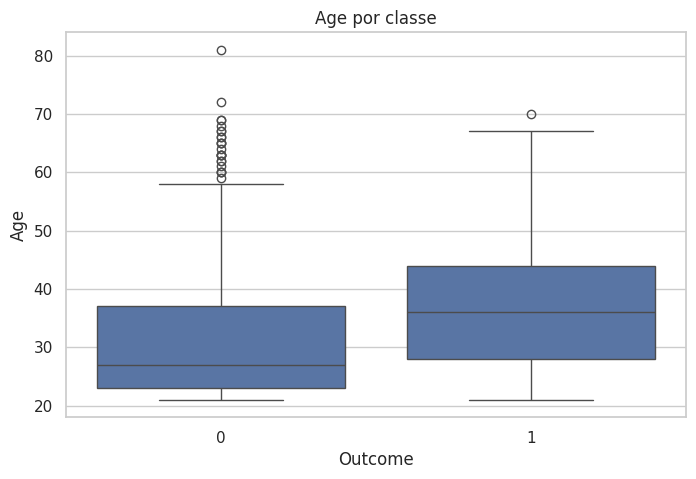

In [ ]:
for coluna in colunas_numericas:
    sns.boxplot(data=df, x="Outcome", y=coluna)
    plt.title(f"{coluna} por classe")
    plt.xlabel("Outcome")
    plt.ylabel(coluna)
    plt.show()

### Interpretação

A comparação entre as classes mostra diferenças relevantes nas medidas centrais de algumas variáveis.

Pacientes com `Outcome = 1` tendem a apresentar maiores valores médios e medianos de `Glucose`, `BMI`, `Age` e `Pregnancies`. Esse padrão sugere que essas variáveis possuem capacidade discriminativa para apoiar a classificação.

A diferença entre média e mediana em algumas variáveis também indica assimetria e possível influência de valores extremos, reforçando a escolha da mediana como estratégia mais robusta para imputação.

Esses resultados sugerem que existe sinal preditivo nos dados, indicando que os modelos de classificação possuem potencial para distinguir as duas classes utilizando a combinação das variáveis disponíveis.

# 13. Relação entre glicose, IMC e diagnóstico

Glicose e IMC são variáveis clinicamente relevantes para diabetes.

O gráfico abaixo permite observar se existe separação visual entre pacientes positivos e negativos considerando essas duas variáveis.

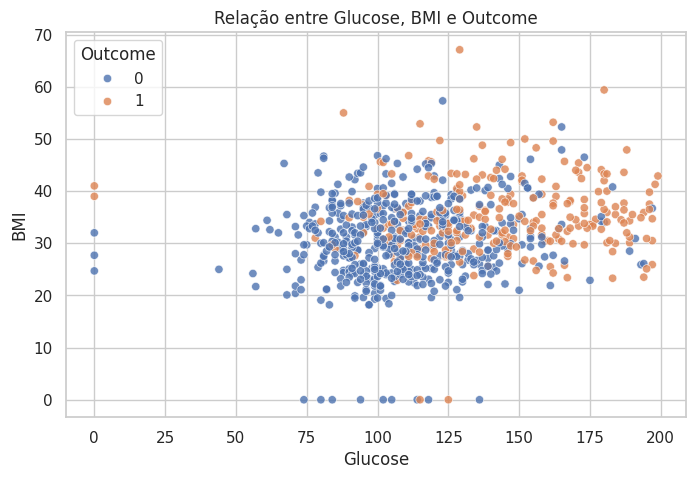

In [ ]:
sns.scatterplot(
    data=df,
    x="Glucose",
    y="BMI",
    hue="Outcome",
    alpha=0.8
)

plt.title("Relação entre Glucose, BMI e Outcome")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

Observa-se uma tendência de concentração dos pacientes com `Outcome = 1` em regiões de maior glicose e maior IMC. Entretanto, existe sobreposição significativa entre as classes.

Essa sobreposição demonstra que nenhuma variável isoladamente é suficiente para discriminar completamente pacientes positivos e negativos. Assim, torna-se necessário utilizar modelos de Machine Learning capazes de combinar simultaneamente múltiplos atributos para construir fronteiras de decisão mais complexas.

# 14. Conclusões da análise exploratória

A análise exploratória permitiu compreender a estrutura do conjunto de dados e identificar características relevantes para as etapas seguintes do projeto.

Foi observado um leve desbalanceamento entre as classes, além da presença de valores iguais a zero em variáveis fisiológicas, indicando possíveis dados ausentes codificados incorretamente. Também foram identificados outliers em diversas variáveis, cuja remoção não se justifica neste momento por poderem representar casos clínicos reais.

As análises indicaram que atributos como `Glucose`, `BMI`, `Age` e `Pregnancies` apresentam diferenças relevantes entre pacientes com e sem indicativo de diabetes, sugerindo potencial preditivo. Esses resultados fundamentam a etapa de pré-processamento e o treinamento dos modelos de Machine Learning.


# 15. EDA após tratamento dos valores clinicamente inválidos

Após identificar valores iguais a zero em variáveis fisiológicas, foi realizada a substituição desses valores por `NaN`, seguida da imputação pela mediana.

Essa etapa tem como objetivo tornar as análises estatísticas mais representativas da realidade clínica antes da construção dos modelos de Machine Learning.

A seguir, são comparadas as distribuições das variáveis após o tratamento.

In [ ]:
df_tratado = df.copy()

colunas_zero_invalidas = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df_tratado[colunas_zero_invalidas] = (
    df_tratado[colunas_zero_invalidas]
    .replace(0, np.nan)
)

for coluna in colunas_zero_invalidas:
    mediana = df_tratado[coluna].median()
    df_tratado[coluna] = df_tratado[coluna].fillna(mediana)

## Comparação das estatísticas antes e depois do tratamento

In [ ]:
comparacao = pd.DataFrame({
    "Média Antes": df.mean(numeric_only=True),
    "Média Depois": df_tratado.mean(numeric_only=True),
    "Mediana Antes": df.median(numeric_only=True),
    "Mediana Depois": df_tratado.median(numeric_only=True)
})

display(comparacao.round(2))

,Média Antes,Média Depois,Mediana Antes,Mediana Depois
Pregnancies,3.85,3.85,3.00,3.00
Glucose,120.89,121.66,117.00,117.00
BloodPressure,69.11,72.39,72.00,72.00
SkinThickness,20.54,29.11,23.00,29.00
Insulin,79.80,140.67,30.50,125.00
BMI,31.99,32.46,32.00,32.30
DiabetesPedigreeFunction,0.47,0.47,0.37,0.37
Age,33.24,33.24,29.00,29.00
Outcome,0.35,0.35,0.00,0.00


Observa-se que as variáveis que continham valores iguais a zero apresentaram alterações principalmente nas médias, refletindo uma representação mais coerente dos dados clínicos.

A mediana sofreu menor impacto, confirmando sua robustez frente a valores extremos e justificando sua utilização como estratégia de imputação neste projeto.

## Distribuição das variáveis após tratamento

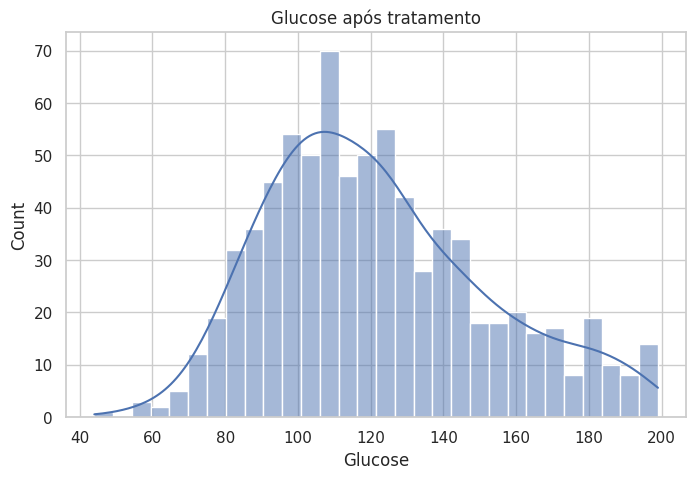

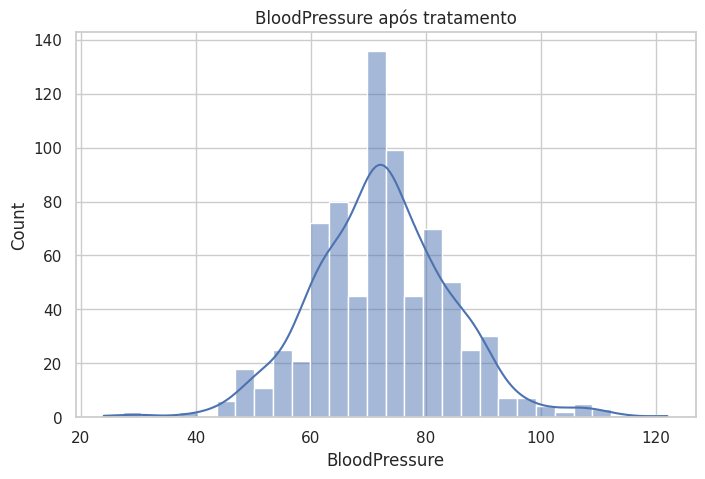

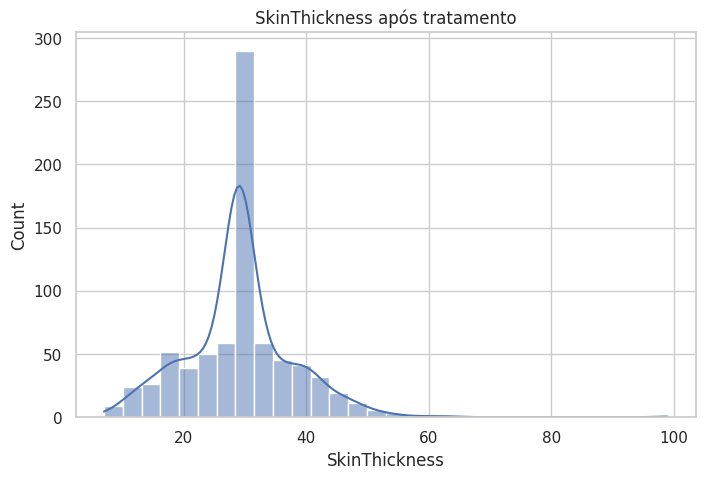

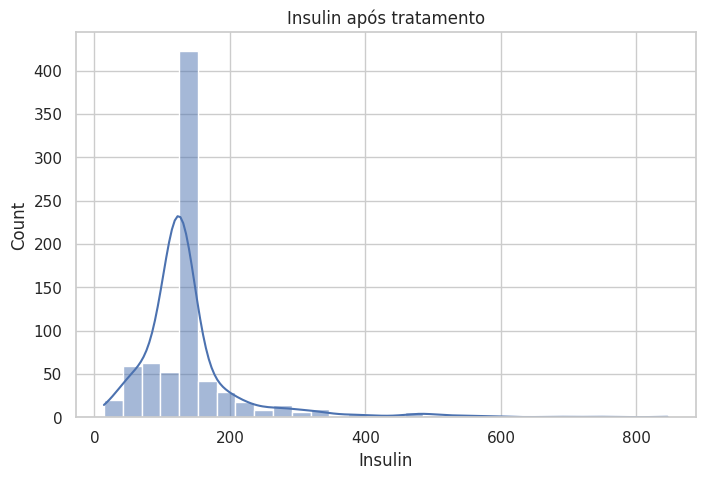

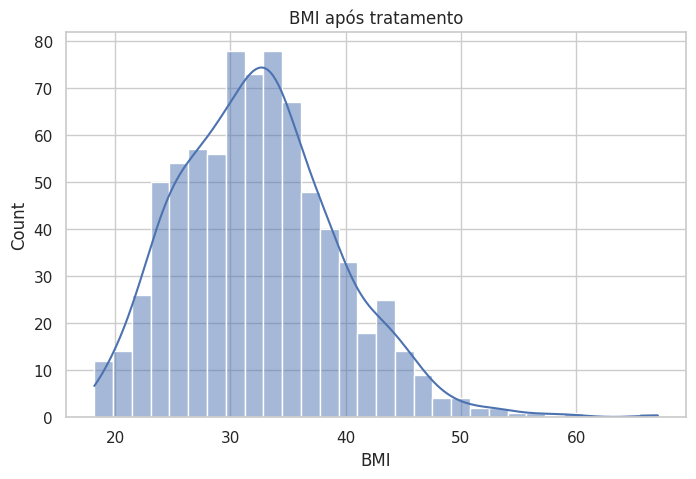

In [ ]:
for coluna in colunas_zero_invalidas:

    sns.histplot(
        data=df_tratado,
        x=coluna,
        kde=True,
        bins=30
    )

    plt.title(f"{coluna} após tratamento")
    plt.show()

Após a imputação, observa-se redução das concentrações artificiais de valores iguais a zero.

As distribuições tornam-se mais compatíveis com o comportamento esperado para variáveis clínicas contínuas, permitindo que as análises posteriores reflitam melhor a realidade dos pacientes avaliados.

## Boxplots após tratamento

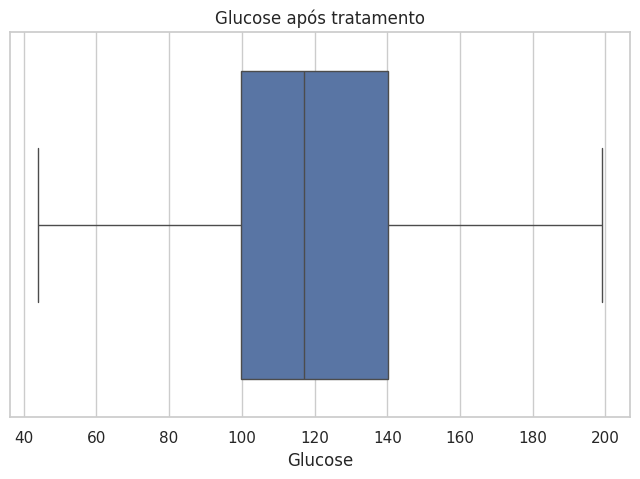

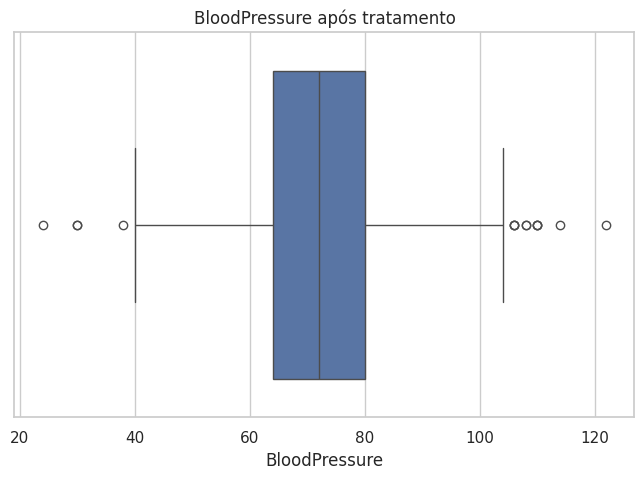

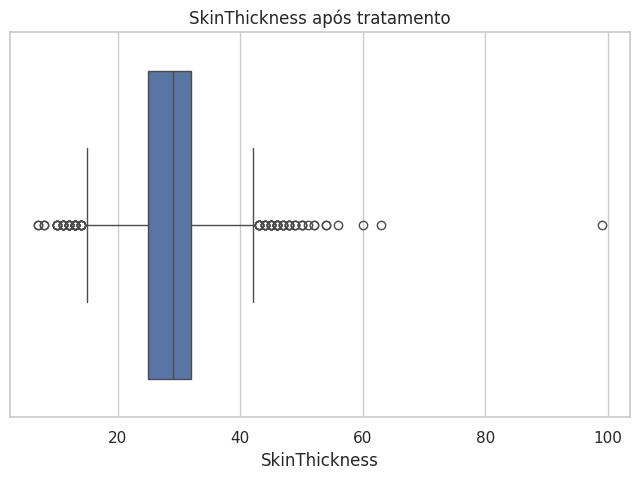

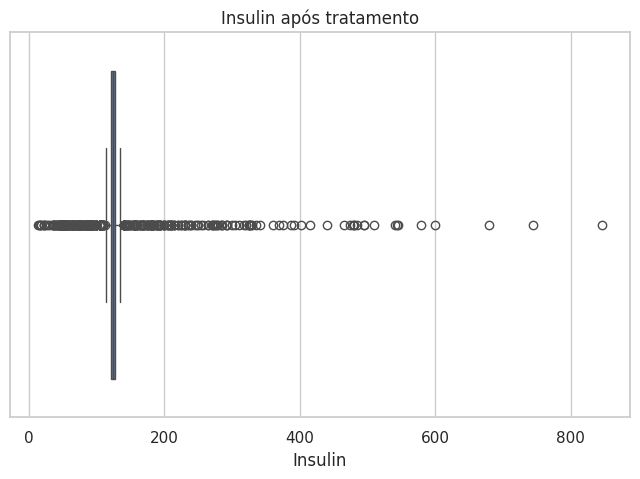

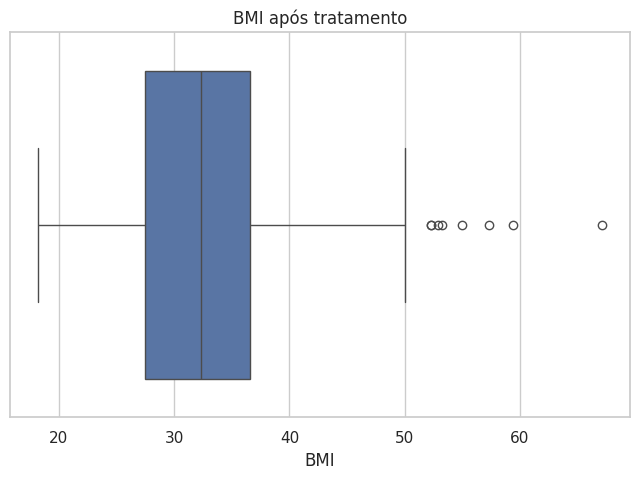

In [ ]:
for coluna in colunas_zero_invalidas:

    sns.boxplot(x=df_tratado[coluna])

    plt.title(f"{coluna} após tratamento")

    plt.show()

Os boxplots mostram que os valores iguais a zero deixaram de concentrar observações na extremidade inferior das distribuições.

Embora ainda existam valores extremos, eles agora representam variações clínicas reais, e não registros ausentes codificados incorretamente.

## Conclusões após o tratamento

A comparação entre os dados originais e os dados tratados mostra que a substituição dos zeros clinicamente inválidos resultou em distribuições mais consistentes para as variáveis fisiológicas.

Esse tratamento reduz distorções estatísticas e fornece uma base mais adequada para o treinamento dos modelos de Machine Learning, aumentando a confiabilidade das análises realizadas nas etapas seguintes.

# 16. Preparação para modelagem

A variável `Outcome` será utilizada como alvo da classificação.

As demais variáveis serão utilizadas como atributos preditores.

In [ ]:
X = df.drop(columns="Outcome")
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (614, 8)
Teste: (154, 8)


# 17. Pré-processamento sem vazamento de dados

Os zeros clinicamente inválidos serão convertidos para NaN dentro do pipeline.

A imputação será feita apenas com dados de treino, evitando vazamento de informação para o conjunto de teste.

Também será aplicado escalonamento para modelos sensíveis à escala, como Regressão Logística.

In [ ]:
def substituir_zeros_invalidos(data):
    data = data.copy()
    data[colunas_zero_invalidas] = data[colunas_zero_invalidas].replace(0, np.nan)
    return data

# 18. Função de avaliação dos modelos

A avaliação será feita considerando múltiplas métricas.

Em diagnóstico médico, o Recall da classe positiva é especialmente importante, pois mede a capacidade do modelo de identificar corretamente pacientes com indicativo da doença.

In [ ]:
def avaliar_modelo(nome, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    metricas = {
        "modelo": nome,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

    print(nome)
    print(classification_report(y_test, y_pred))

    matriz = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Não diabético", "Diabético"],
        yticklabels=["Não diabético", "Diabético"]
    )

    plt.title(f"Matriz de confusão - {nome}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

    RocCurveDisplay.from_estimator(modelo, X_test, y_test)
    plt.title(f"Curva ROC - {nome}")
    plt.show()

    return metricas

# 19. Modelo 1 — Regressão Logística

A Regressão Logística é um modelo simples, interpretável e adequado como baseline para problemas de classificação binária.

# Ela é sensível à escala das variáveis, por isso será utilizada com padronização.

Regressão Logística
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



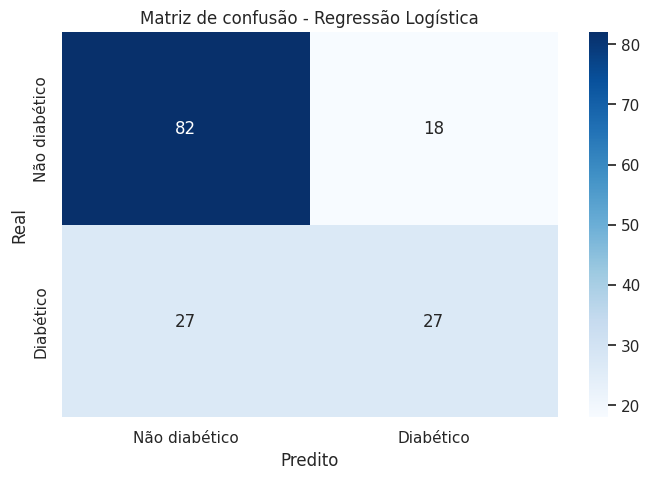

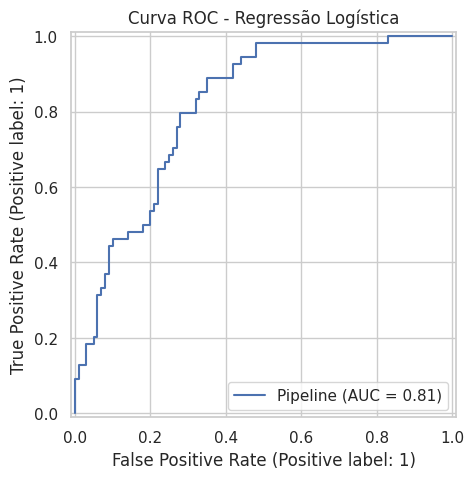

In [ ]:
from sklearn.preprocessing import FunctionTransformer

preprocessamento_linear = Pipeline(steps=[
    ("zeros_invalidos", FunctionTransformer(substituir_zeros_invalidos)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

modelo_logistico = Pipeline(steps=[
    ("preprocessamento", preprocessamento_linear),
    ("modelo", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

modelo_logistico.fit(X_train, y_train)

resultado_logistico = avaliar_modelo(
    "Regressão Logística",
    modelo_logistico,
    X_test,
    y_test
)

# 20. Modelo 2 — Árvore de Decisão

A Árvore de Decisão é um modelo interpretável e capaz de capturar relações não lineares.

Entretanto, possui alto risco de overfitting quando não há controle de profundidade.

Árvore de Decisão
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       100
           1       0.70      0.69      0.69        54

    accuracy                           0.79       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.79      0.79       154



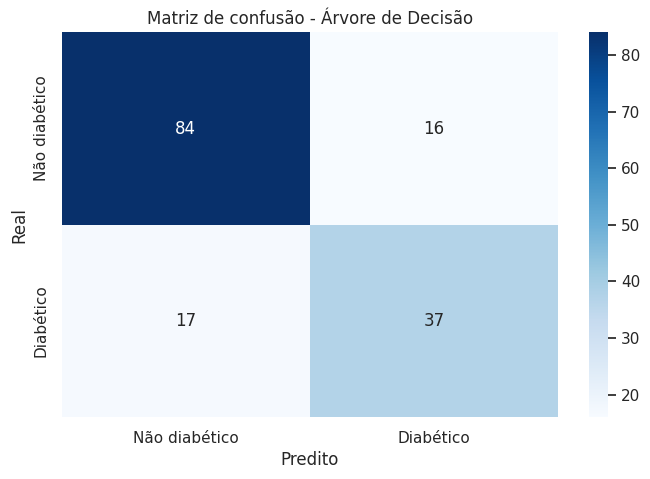

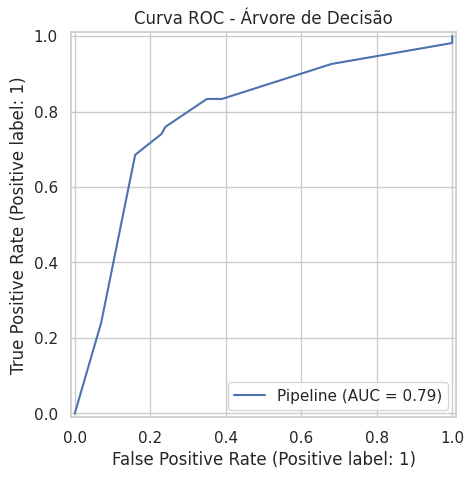

In [ ]:
preprocessamento_arvore = Pipeline(steps=[
    ("zeros_invalidos", FunctionTransformer(substituir_zeros_invalidos)),
    ("imputer", SimpleImputer(strategy="median"))
])

modelo_arvore = Pipeline(steps=[
    ("preprocessamento", preprocessamento_arvore),
    ("modelo", DecisionTreeClassifier(
        max_depth=4,
        random_state=RANDOM_STATE
    ))
])

modelo_arvore.fit(X_train, y_train)

resultado_arvore = avaliar_modelo(
    "Árvore de Decisão",
    modelo_arvore,
    X_test,
    y_test
)

# 21. Modelo 3 — Random Forest

Random Forest combina múltiplas árvores de decisão, reduzindo o risco de overfitting em comparação com uma única árvore.

É um modelo robusto, mas menos interpretável que a Regressão Logística ou uma Árvore de Decisão simples.

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.74      0.78       100
           1       0.60      0.72      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



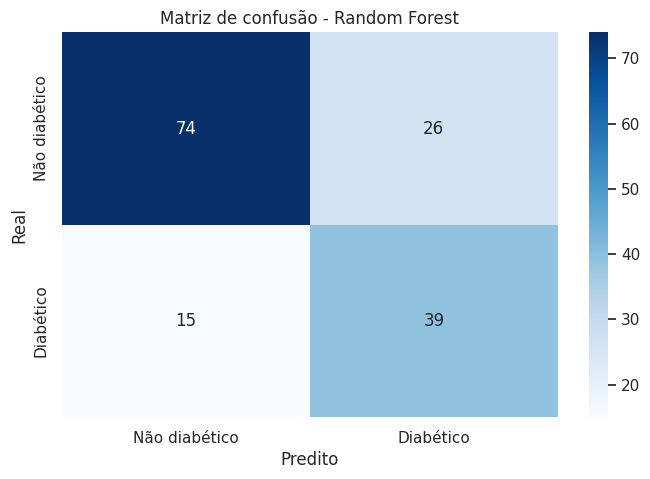

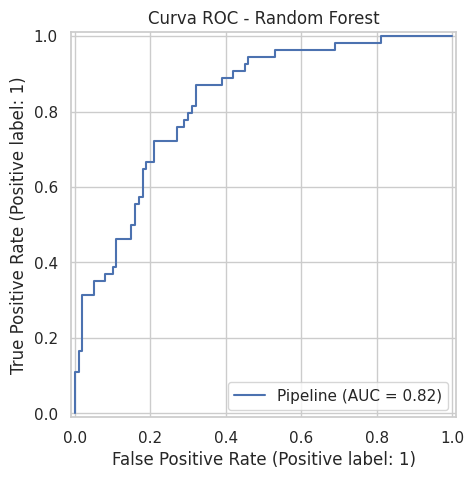

In [ ]:
modelo_random_forest = Pipeline(steps=[
    ("preprocessamento", preprocessamento_arvore),
    ("modelo", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

modelo_random_forest.fit(X_train, y_train)

resultado_random_forest = avaliar_modelo(
    "Random Forest",
    modelo_random_forest,
    X_test,
    y_test
)

# 22. Comparação dos modelos

A comparação dos modelos deve considerar o contexto médico.

Embora Accuracy seja útil, ela pode mascarar falhas importantes. Para diagnóstico, o Recall da classe positiva é essencial, pois falsos negativos representam pacientes possivelmente doentes que não seriam sinalizados pelo sistema.

In [ ]:
resultados = pd.DataFrame([
    resultado_logistico,
    resultado_arvore,
    resultado_random_forest
])

display(resultados.sort_values(by="recall", ascending=False).round(4))

,modelo,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,0.7338,0.6000,0.7222,0.6555,0.8231
1,Árvore de Decisão,0.7857,0.6981,0.6852,0.6916,0.7887
0,Regressão Logística,0.7078,0.6000,0.5000,0.5455,0.8130


## Discussão dos resultados dos modelos

A comparação entre os modelos evidencia que nenhum algoritmo apresentou desempenho superior em todas as métricas avaliadas.

A Árvore de Decisão obteve maior Accuracy, Precision e F1-score, enquanto o Random Forest apresentou maior Recall e ROC-AUC.

Considerando o contexto clínico deste estudo, optou-se pela utilização do Random Forest como modelo final, uma vez que o Recall é particularmente importante para reduzir a ocorrência de falsos negativos, além do melhor desempenho apresentado em ROC-AUC, indicando maior capacidade discriminativa entre as classes.

# 23. Validação cruzada

A validação cruzada permite avaliar a estabilidade do modelo em diferentes divisões dos dados.

Isso reduz a dependência de uma única separação treino/teste.

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_resultados = cross_validate(
    modelo_random_forest,
    X,
    y,
    cv=cv,
    scoring=scoring
)

cv_metricas = pd.DataFrame(cv_resultados).filter(like="test_")
display(cv_metricas.mean().round(4).to_frame("media"))
display(cv_metricas.std().round(4).to_frame("desvio_padrao"))

,media
test_accuracy,0.7590
test_precision,0.6371
test_recall,0.7352
test_f1,0.6811
test_roc_auc,0.8348


,desvio_padrao
test_accuracy,0.0355
test_precision,0.0531
test_recall,0.0416
test_f1,0.0354
test_roc_auc,0.0232


# 24. Importância das variáveis

A análise de importância das variáveis ajuda a entender quais atributos mais contribuíram para as decisões do modelo.

Essa etapa é importante em problemas médicos, pois permite avaliar se o comportamento do modelo é coerente com o conhecimento clínico.

,variavel,importancia
1,Glucose,0.326760
5,BMI,0.177633
7,Age,0.121289
4,Insulin,0.110524
6,DiabetesPedigreeFunction,0.087744
3,SkinThickness,0.061907
2,BloodPressure,0.057915
0,Pregnancies,0.056228


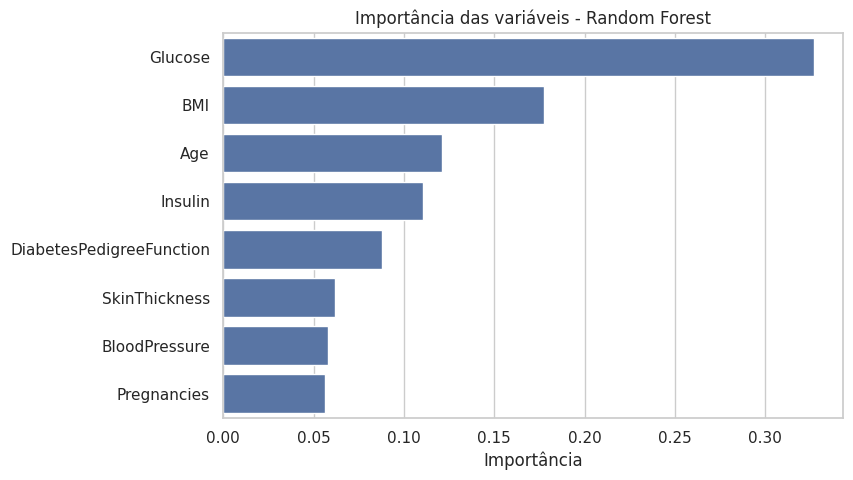

In [ ]:
modelo_rf_treinado = modelo_random_forest.named_steps["modelo"]

importancias = pd.DataFrame({
    "variavel": X.columns,
    "importancia": modelo_rf_treinado.feature_importances_
}).sort_values(by="importancia", ascending=False)

display(importancias)

sns.barplot(
    data=importancias,
    x="importancia",
    y="variavel"
)

plt.title("Importância das variáveis - Random Forest")
plt.xlabel("Importância")
plt.ylabel("")
plt.show()

## Discussão da importância das variáveis

A análise de importância das variáveis demonstra que a glicose foi o atributo de maior contribuição para as decisões do modelo, resultado consistente com o conhecimento clínico sobre diabetes.

Também apresentaram relevância variáveis como BMI, Age, Insulin e DiabetesPedigreeFunction, indicando que o risco da doença depende da interação entre múltiplos fatores fisiológicos e históricos.

Embora a importância das variáveis permita compreender melhor o comportamento do modelo, ela não estabelece relações de causalidade. Os resultados devem ser interpretados como evidências estatísticas do processo de aprendizado do algoritmo e não como confirmação de relações clínicas diretas.

### Interpretação

A análise de importância das variáveis indica que `Glucose` foi o principal atributo utilizado pelo modelo Random Forest para tomada de decisão. Esse resultado é clinicamente coerente, pois a glicose está diretamente relacionada ao diagnóstico de diabetes.

Variáveis como `BMI`, `Age`, `Insulin` e `DiabetesPedigreeFunction` também contribuem para o modelo, sugerindo que o risco de diabetes não depende de um único fator isolado.

Apesar disso, Feature Importance deve ser interpretada com cautela. Ela indica relevância para o modelo, mas não mostra causalidade nem explica, sozinha, a direção do impacto de cada variável. Para uma análise mais robusta, SHAP seria uma alternativa mais adequada.

# 25. Discussão crítica

O modelo desenvolvido apresenta potencial para apoiar uma triagem inicial de pacientes com risco de diabetes, mas não deve ser interpretado como ferramenta diagnóstica definitiva.

Em contexto médico, o principal risco está nos falsos negativos, ou seja, pacientes com indicativo de diabetes classificados incorretamente como não diabéticos. Por esse motivo, métricas como Recall, F1-score e ROC-AUC devem receber mais atenção do que Accuracy.

Também existem limitações importantes:

- o dataset possui tamanho reduzido;
- os dados representam uma população específica;
- algumas variáveis possuem valores clinicamente inválidos codificados como zero;
- não há informações sobre exames laboratoriais mais completos;
- não há validação externa com dados de outro hospital;
- o modelo pode apresentar viés se a base não representar diferentes perfis populacionais.

Portanto, este modelo poderia ser utilizado apenas como apoio exploratório ou ferramenta de priorização inicial, nunca como substituto da avaliação médica.

Além dos aspectos quantitativos, a utilização de modelos de Machine Learning em saúde exige atenção a questões éticas, transparência e responsabilidade na tomada de decisão. Dessa forma, o sistema proposto deve ser entendido como um mecanismo de apoio ao diagnóstico, fornecendo informações complementares aos profissionais de saúde, que permanecem responsáveis pela decisão clínica final.

## 26. Limitações do estudo

Apesar dos resultados obtidos demonstrarem potencial para utilização em sistemas de apoio ao diagnóstico, este estudo apresenta algumas limitações importantes.

O conjunto de dados contém apenas 768 registros, provenientes de uma população específica, o que pode limitar a capacidade de generalização do modelo para diferentes hospitais ou perfis populacionais.

Outro ponto relevante é a presença de valores iguais a zero em variáveis fisiológicas, interpretados como dados ausentes e tratados por imputação. Embora essa abordagem seja amplamente utilizada, ela introduz uma aproximação estatística que pode não representar perfeitamente todos os pacientes.

Além disso, o estudo foi desenvolvido utilizando apenas um conjunto de dados público, sem validação externa em bases independentes, impossibilitando afirmar que o desempenho observado será reproduzido em ambiente clínico real.

Por essas razões, o modelo deve ser interpretado como uma ferramenta de apoio à decisão médica, auxiliando a triagem inicial de pacientes, e não como substituto da avaliação realizada por profissionais de saúde.

# 27. Conclusão

O objetivo deste projeto foi desenvolver uma solução baseada em Machine Learning para auxiliar na identificação de pacientes com indicativo de diabetes a partir de variáveis clínicas estruturadas.

Durante a análise exploratória foram identificadas inconsistências importantes, principalmente valores iguais a zero em variáveis fisiológicas, interpretados como possíveis dados ausentes. Esses registros foram tratados por meio de imputação utilizando a mediana dentro de um Pipeline de pré-processamento, evitando vazamento de dados entre treino e teste.

Foram avaliados três algoritmos de classificação: Regressão Logística, Árvore de Decisão e Random Forest.

Embora a Árvore de Decisão tenha obtido maior Accuracy, Precision e F1-score, o Random Forest foi selecionado como modelo final por apresentar maior Recall e ROC-AUC. Considerando o contexto de apoio ao diagnóstico médico, priorizou-se a capacidade do modelo em identificar corretamente pacientes com diabetes, reduzindo a ocorrência de falsos negativos.

- Accuracy: **73,38%**
- Precision: **60,00%**
- Recall: **72,22%**
- F1-score: **65,55%**
- ROC-AUC: **82,31%**


Validação cruzada:

- Accuracy média: **75,90%**
- Precision média: **63,71%**
- Recall médio: **73,52%**
- F1-score médio: **68,11%**
- ROC-AUC médio: **83,48%**

Os resultados obtidos demonstram que o Random Forest apresentou o melhor desempenho para os objetivos deste estudo, destacando-se principalmente pelo maior Recall e ROC-AUC entre os modelos avaliados.

Na validação cruzada, o modelo manteve desempenho consistente, indicando boa capacidade de generalização para o conjunto de dados utilizado.

A escolha do Random Forest foi motivada principalmente pelo maior valor de Recall. Em aplicações de apoio ao diagnóstico médico, essa métrica possui maior relevância do que a Accuracy isoladamente, pois reduz a probabilidade de pacientes com diabetes serem classificados incorretamente como saudáveis, minimizando a ocorrência de falsos negativos.

Os resultados demonstram que técnicas de Machine Learning possuem potencial para apoiar sistemas inteligentes de triagem clínica. Entretanto, devido às limitações do conjunto de dados e à ausência de validação externa, o modelo deve ser interpretado como ferramenta de apoio à decisão médica, não substituindo a avaliação realizada por profissionais de saúde.

# 28. Trabalhos futuros

Como continuidade deste projeto, algumas melhorias podem ser exploradas:

- otimização de hiperparâmetros utilizando GridSearchCV ou RandomizedSearchCV;
- avaliação de modelos adicionais, como XGBoost e LightGBM;
- utilização de SHAP para interpretação detalhada das previsões;
- validação em bases de dados externas;
- desenvolvimento de uma API para integração do modelo com sistemas hospitalares;
- monitoramento contínuo do desempenho após implantação em produção;
- comparação do desempenho do modelo em diferentes populações utilizando validação externa;
- avaliação do impacto do ajuste do threshold na redução de falsos negativos em aplicações de apoio ao diagnóstico médico;

## 29. Considerações finais

Ao longo deste projeto foi possível aplicar todas as etapas clássicas de um fluxo de Ciência de Dados, desde a compreensão do problema de negócio até a avaliação crítica dos modelos de Machine Learning.

Mais do que obter boas métricas, buscou-se compreender a qualidade dos dados, justificar cada decisão de pré-processamento e interpretar os resultados sob a perspectiva do domínio médico, desenvolvendo uma solução alinhada às boas práticas de Ciência de Dados e Machine Learning para apoio ao diagnóstico clínico.